In [1]:
%load_ext water_quality.magics

In [2]:
from water_quality.logs import setup_logging
log = setup_logging()

In [3]:
import xarray as xr
from datacube import Datacube
# Useful later the year to plot for
year = "2023"

# Load the instrument data generated using the prototyping WP1.2 notebooks
wp_12_data_xr = xr.open_dataset("loaded_anual_instrument_data.nc", engine='h5netcdf')
wp_12_data_xr

2026-02-21 19:38:21,572 numexpr.utils [INFO]: NumExpr defaulting to 4 threads.


<xarray.Dataset> Size: 66MB
Dimensions:              (time: 25, y: 170, x: 76)
Coordinates:
  * time                 (time) datetime64[ns] 200B 2000-07-01T23:59:59.99999...
  * y                    (y) float64 1kB 5.731e+04 5.753e+04 ... 9.449e+04
  * x                    (x) float64 608B 3.473e+06 3.474e+06 ... 3.49e+06
    spatial_ref          int32 4B ...
Data variables: (12/39)
    oli02_agm            (time, y, x) float64 3MB ...
    oli03_agm            (time, y, x) float64 3MB ...
    oli04_agm            (time, y, x) float64 3MB ...
    oli05_agm            (time, y, x) float64 3MB ...
    oli06_agm            (time, y, x) float64 3MB ...
    oli07_agm            (time, y, x) float64 3MB ...
    ...                   ...
    wofs_ann_freq        (time, y, x) float32 1MB ...
    wofs_ann_clearcount  (time, y, x) float64 3MB ...
    wofs_ann_wetcount    (time, y, x) float64 3MB ...
    tirs_st_ann_med      (time, y, x) float64 3MB ...
    tirs_st_ann_min      (time, y, x) float64 3MB ...
    tirs_st_ann_max      (time, y, x) float64 3MB ...
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

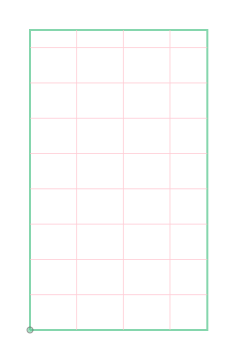

In [4]:
tile_geobox = wp_12_data_xr.odc.geobox
tile_geobox

In [5]:
import rioxarray

water_temp_bands = ["tirs_st_ann_min", "tirs_st_ann_med",  "tirs_st_ann_max"]
filepath_template = "test/wq_annual/1-0-0/x217/y077/2023--P1Y/wq_annual_x217y077_2023--P1Y_band.tif"
file_list = [filepath_template.replace("band", band) for band in water_temp_bands]

wq_ds = {}
wq_ds["water_temp"] = xr.Dataset({
    name: rioxarray.open_rasterio(path).squeeze(drop=True) 
    for name, path in zip(water_temp_bands, file_list)
})
wq_ds["water_temp"]

<xarray.Dataset> Size: 312kB
Dimensions:          (x: 76, y: 170)
Coordinates:
  * x                (x) float64 608B 3.473e+06 3.474e+06 ... 3.49e+06 3.49e+06
  * y                (y) float64 1kB 5.731e+04 5.753e+04 ... 9.427e+04 9.449e+04
    spatial_ref      int64 8B 0
Data variables:
    tirs_st_ann_min  (y, x) float64 103kB ...
    tirs_st_ann_med  (y, x) float64 103kB ...
    tirs_st_ann_max  (y, x) float64 103kB ...

In [6]:
def required_counts(da_):
    valid_pixels = da_.count().item()
    total_pixels = da_.size
    return f"{valid_pixels} valid_pixels \n {total_pixels} total pixels"

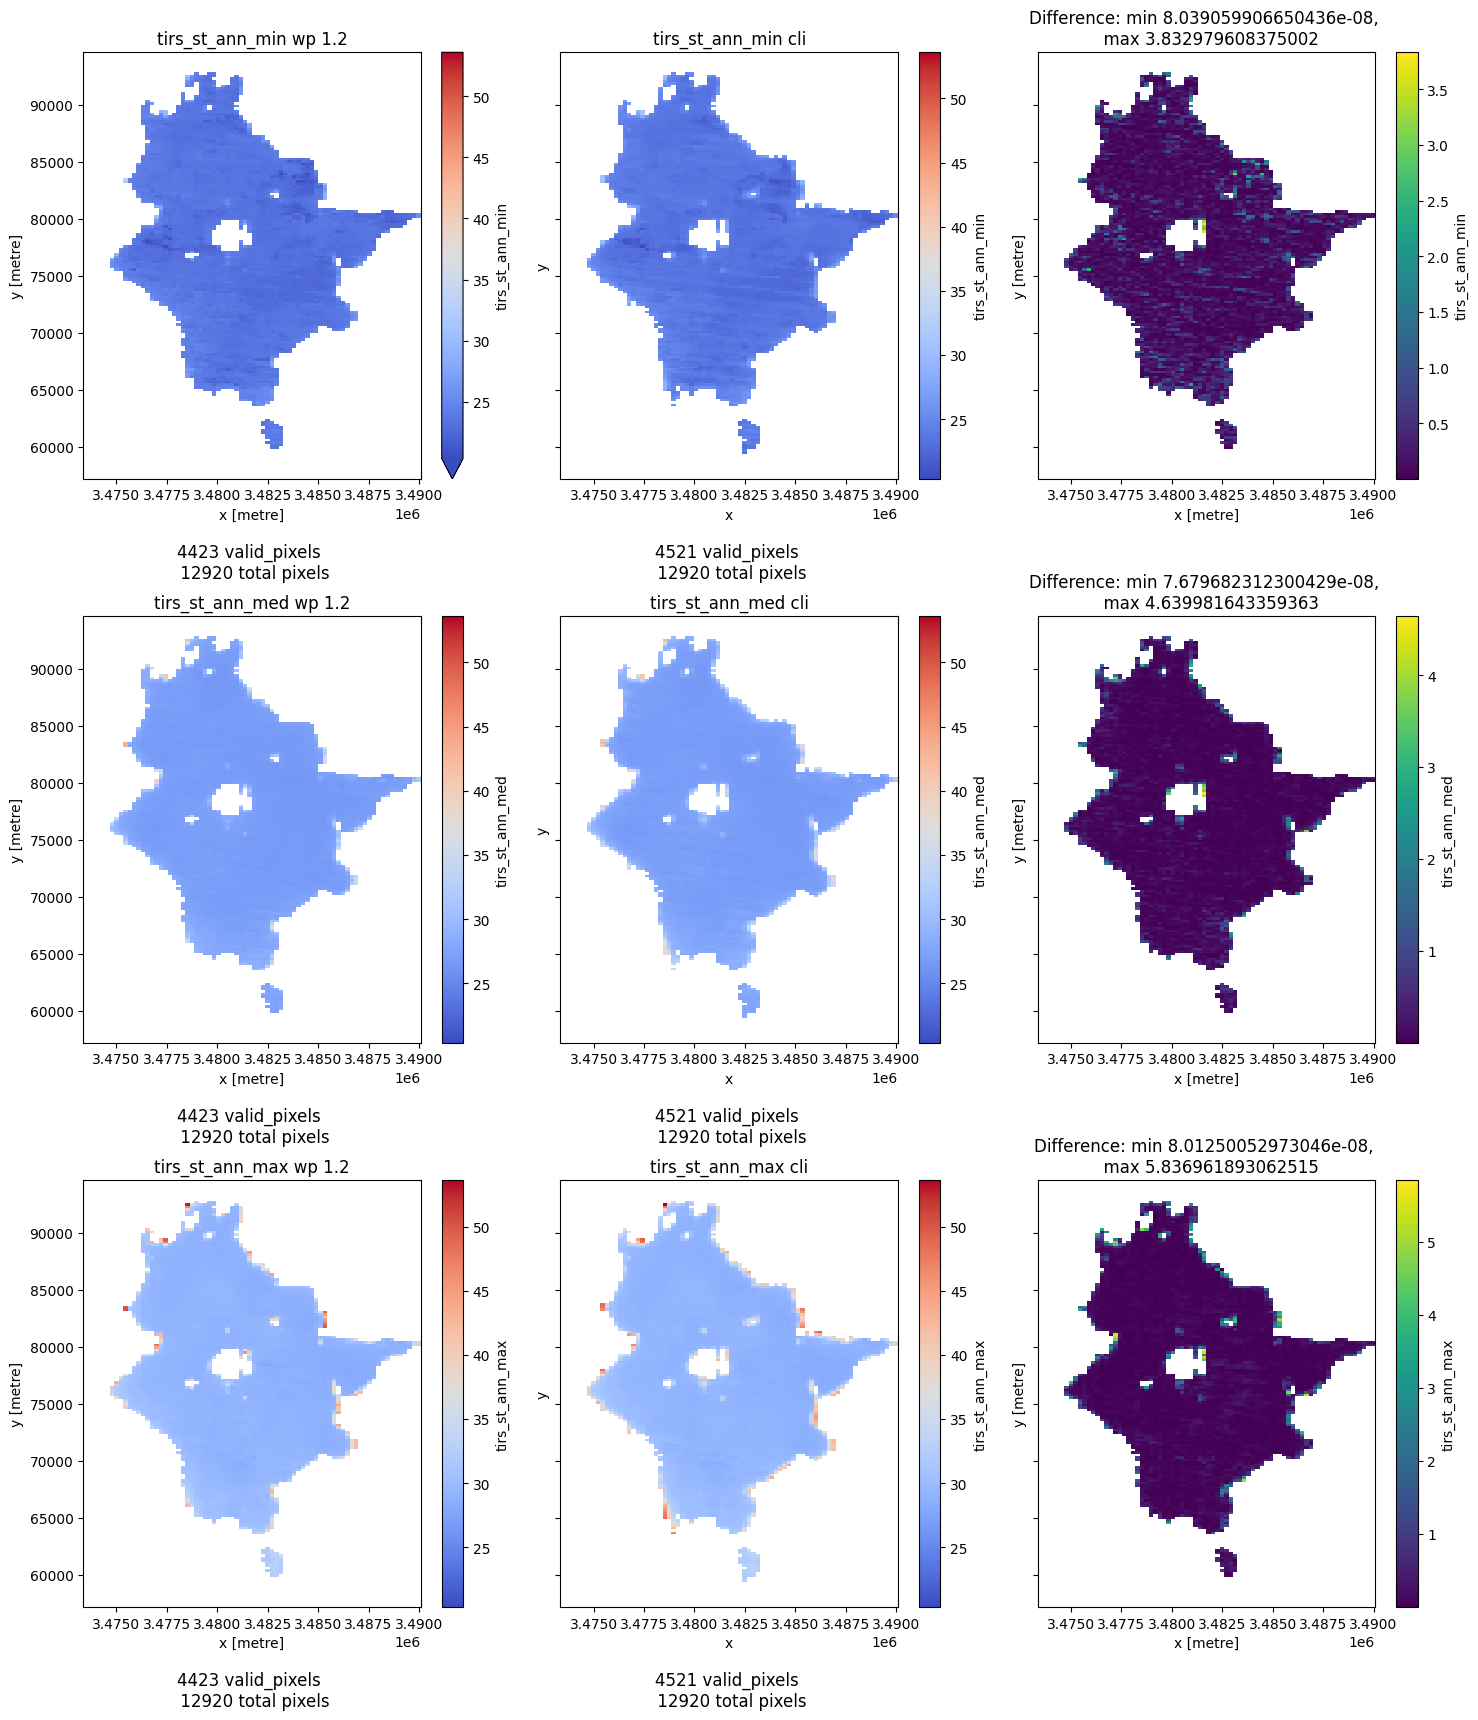

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


n_variables = 3
n_plots_per_variable = 3
ncols = n_plots_per_variable  # columns for ref, da, and diff plots
nrows = n_variables           # rows for each variable

fig, axs = plt.subplots(nrows, ncols, sharey=True, figsize=(15, 6 * nrows))

water_temp_bands = list(wq_ds["water_temp"].data_vars)

vmin = min([float(wq_ds["water_temp"][band].min()) for band in water_temp_bands])
vmax = max([float(wq_ds["water_temp"][band].max()) for band in water_temp_bands])

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = "coolwarm"

for var in water_temp_bands:
    i = water_temp_bands.index(var)
    ref_da = wp_12_data_xr[var].sel(time=year)
    da = wq_ds["water_temp"][var]
    diff = np.abs(ref_da - da)
    
    min_diff = diff.min().item()
    max_diff = diff.max().item() 

    # --- Plotting within the loop, using the row index 'i' ---
    # Plot 'ref_da' on the first column of the current row
    ref_da.plot( cmap=cmap, norm=norm, ax=axs[i, 0])
    axs[i, 0].text(0.5, -0.15, required_counts(ref_da), 
                transform=axs[i, 0].transAxes, 
                ha='center', va='top', fontsize=12)
    axs[i, 0].set_title(f"{var} wp 1.2")

    # Plot 'da' on the second column of the current row
    da.plot( cmap=cmap, norm=norm, ax=axs[i, 1])
    axs[i, 1].set_title(f"{var} cli")
    axs[i, 1].text(0.5, -0.15, required_counts(da), 
                transform=axs[i, 1].transAxes, 
                ha='center', va='top', fontsize=12)

    # Plot 'diff' on the third column of the current row
    diff.plot(ax=axs[i, 2])
    axs[i, 2].set_title(f"Difference: min {min_diff}, \n  max {max_diff}")
        
plt.tight_layout(rect=[0, 0, 1, 0.96]) # rect argument is used to make space for suptitle
plt.savefig('water_temp_comparison.png', dpi=200)

# Optional: Display the final plot
plt.show()